In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [6]:
# 원본 이미지 읽기
img_original = cv2.imread("../images/person2.jpg")
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

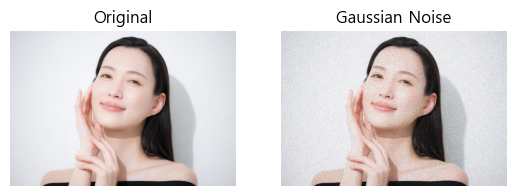

In [7]:
# 전체적으로 거친 노이즈 이미지 생성 
# - sigma: 표준편차(클수록 노이즈 강함)
def add_gaussian_noise(image_rgb, sigma) -> np.ndarray:
    noise = np.random.normal(0, sigma, image_rgb.shape).astype(np.float32)
    noisy = image_rgb.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)
img_gaussian_noisy = add_gaussian_noise(img_original, sigma=30.0)

# 시각화
fig, axes = plt.subplots(1, 2)

axes[0].set_title("Original")
axes[0].imshow(img_original)
axes[0].axis("off")

axes[1].set_title("Gaussian Noise")
axes[1].imshow(img_gaussian_noisy)
axes[1].axis("off")

plt.show()

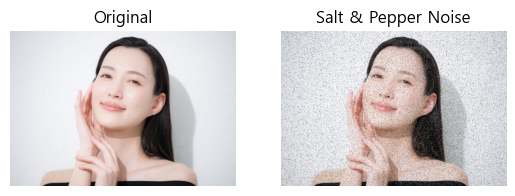

In [8]:
# 소금-후추 노이즈 이미지 생성 (일부 픽셀이 0(검정색) 또는 255(흰색)로 튐)
# amount: 전체 픽셀 중 노이즈가 들어갈 비율 (예: 0.1 = 10%)
# salt_vs_pepper: 노이즈 중 흰색과 검은색 비율(0.5 = 흰색 50%, 검은색 50%)
def add_salt_pepper_noise(image_rgb, amount, salt_vs_pepper) -> np.ndarray:
    noisy = image_rgb.copy()
    h, w = noisy.shape[:2]
    num_pixels = h * w
    num_noisy = int(num_pixels * amount)

    # Salt
    num_salt = int(num_noisy * salt_vs_pepper)
    ys = np.random.randint(0, h, num_salt)
    xs = np.random.randint(0, w, num_salt)
    noisy[ys, xs] = 255

    # Pepper
    num_pepper = num_noisy - num_salt
    ys = np.random.randint(0, h, num_pepper)
    xs = np.random.randint(0, w, num_pepper)
    noisy[ys, xs] = 0

    return noisy
img_sp_noisy = add_salt_pepper_noise(img_original, amount=0.1, salt_vs_pepper=0.5)

# 시각화
fig, axes = plt.subplots(1, 2)

axes[0].set_title("Original")
axes[0].imshow(img_original)
axes[0].axis("off")

axes[1].set_title("Salt & Pepper Noise")
axes[1].imshow(img_sp_noisy)
axes[1].axis("off")

plt.show()

In [9]:
# 블러 적용 함수: 세 가지 블러 결과를 dict로 반환
def apply_blurs(image_rgb, k) -> dict:
    # 평균 블러 적용
    blur = cv2.blur(image_rgb, (k, k))
    
    # 가우시안 블러 적용
    # - sigmaX: 가우시안 커널의 표준편차 (클수록 더 부드러운 블러)    
    # - sigmaX=0이면 자동 계산
    gaussian = cv2.GaussianBlur(image_rgb, (k, k), sigmaX=0)
    
    # 미디언 블러 적용: 커널 크기만 받음
    median = cv2.medianBlur(image_rgb, k)
    return {
        "Blur": blur,
        "GaussianBlur": gaussian,
        "MedianBlur": median
    }

# 블러 적용
gaussian_results = apply_blurs(img_gaussian_noisy, k=9)
sp_results = apply_blurs(img_sp_noisy, k=9)

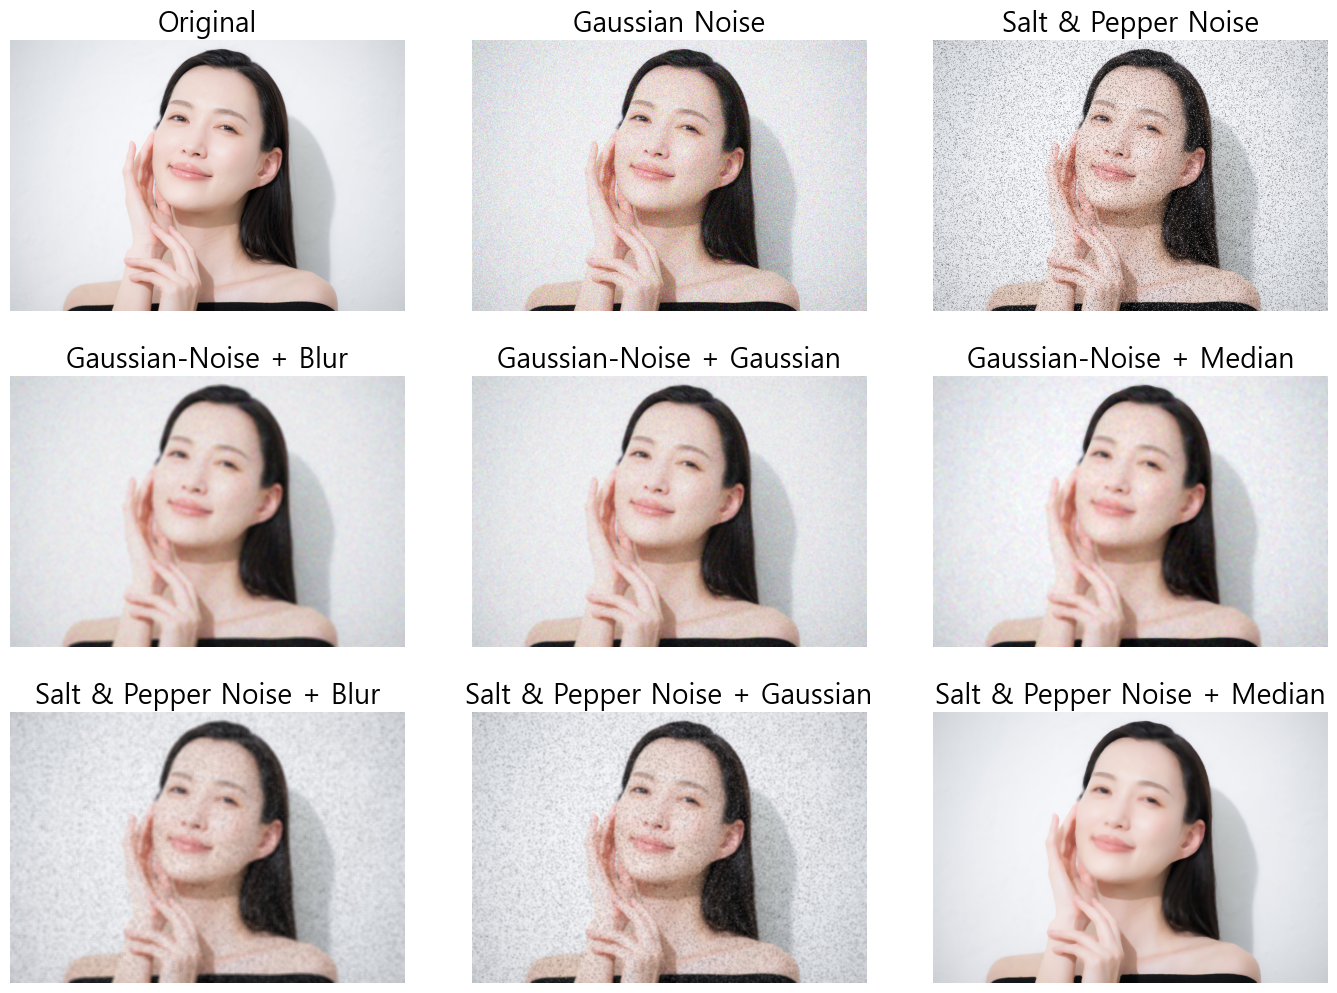

In [10]:
# Figure 생성
fig, axes = plt.subplots(3, 3, figsize=(14, 10))

# 1행: 원본 + 노이즈 2종
axes[0, 0].set_title("Original", fontsize=20)
axes[0, 0].imshow(img_original)
axes[0, 0].axis("off")

axes[0, 1].set_title("Gaussian Noise", fontsize=20)
axes[0, 1].imshow(img_gaussian_noisy)
axes[0, 1].axis("off")

axes[0, 2].set_title("Salt & Pepper Noise", fontsize=20)
axes[0, 2].imshow(img_sp_noisy)
axes[0, 2].axis("off")

# 2행: 가우시안 노이즈에 대한 블러 3종
axes[1, 0].set_title("Gaussian-Noise + Blur", fontsize=20)
axes[1, 0].imshow(gaussian_results["Blur"])
axes[1, 0].axis("off")

axes[1, 1].set_title("Gaussian-Noise + Gaussian", fontsize=20)
axes[1, 1].imshow(gaussian_results["GaussianBlur"])
axes[1, 1].axis("off")

axes[1, 2].set_title("Gaussian-Noise + Median", fontsize=20)
axes[1, 2].imshow(gaussian_results["MedianBlur"])
axes[1, 2].axis("off")

# 3행: 소금-후추 노이즈에 대한 블러 3종
axes[2, 0].set_title("Salt & Pepper Noise + Blur", fontsize=20)
axes[2, 0].imshow(sp_results["Blur"])
axes[2, 0].axis("off")

axes[2, 1].set_title("Salt & Pepper Noise + Gaussian", fontsize=20)
axes[2, 1].imshow(sp_results["GaussianBlur"])
axes[2, 1].axis("off")

axes[2, 2].set_title("Salt & Pepper Noise + Median", fontsize=20)
axes[2, 2].imshow(sp_results["MedianBlur"])
axes[2, 2].axis("off")

# 레이아웃 여백 조정
fig.tight_layout(h_pad=3.0)

# 그래프 출력
plt.show()